In [1]:
import json
import multiprocessing as mp
import pickle

import numpy as np
import torch
from matplotlib import pyplot as plt

from src.models import BinaryClassifier
from src.utils import get_filepath
from src.priors import (
    build_priors,
    describe_prior_normalization,
    draw_grid_samples,
    get_alignment_support_axes,
    integrate_nd_vegas,
    snap_to_support_axis,
)
from src.data import draw_data, get_data
from src.training import train, test_model
from src.plotting import (
    _enforce_markers,
    plot_all_rocs,
    plot_error_and_hld_width,
    plot_errorbars,
    plot_log_ratio_error_vs_distance,
    plot_log_ratio_exact_vs_predicted,
    plot_prior_contours,
    plot_prior_sample_histograms,
    plot_ratio_violins,
    plot_reweighting_summary,
    plot_reweighted_distributions,
    plot_reweighting_swd_vs_distance,
    plot_training_tests,
)
from src.posterior import (
    create_inference_data,
    create_inference_parameters,
    get_first_column_scatter_data,
    get_posteriors_and_errors,
)
from src.verification import (
    build_quantitative_verification_bundle,
    calculate_all_ratios,
    evaluate_nd_reweighting_quality,
    evaluate_pairwise_log_ratio_quality,
    reweight_distributions,
)

plt.rc("axes", prop_cycle=plt.cycler(color=plt.get_cmap("Set1").colors))


In [ ]:
config = {
    "data": {
        "prior_args": {
            "uniform": None,
            "normal": (5, 4),
            "exponential": (0.1,),
            "grid": (0.2,),
        },
        "parameter_range": (0, 10),
        "std_dev": 2,
        "n_parameters": 1,
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000,
    },
    "classifier": {
        "n_inputs": 1, #has to be equal to n_parameters
        "n_hidden_layers": 3,
        "n_units": 64,
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5,
        "model_iterations": 1,
    },
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)


In [ ]:
priors, prior_samplers, param_min, param_max = build_priors(config, generator)
alignment_support_axes = get_alignment_support_axes(priors)
alignment_support_axes


(array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,
         2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,
         4.4,  4.6,  4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,
         6.6,  6.8,  7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,
         8.8,  9. ,  9.2,  9.4,  9.6,  9.8, 10. ], dtype=float32),)

#### Prior Distirbutions:

In [4]:
plot_prior_contours(
    priors,
    parameter_range=config["data"]["parameter_range"],
    n_parameters=config["data"]["n_parameters"],
)

IndexError: index 1 is out of bounds for axis 2 with size 1

IndexError: index 1 is out of bounds for axis 1 with size 1

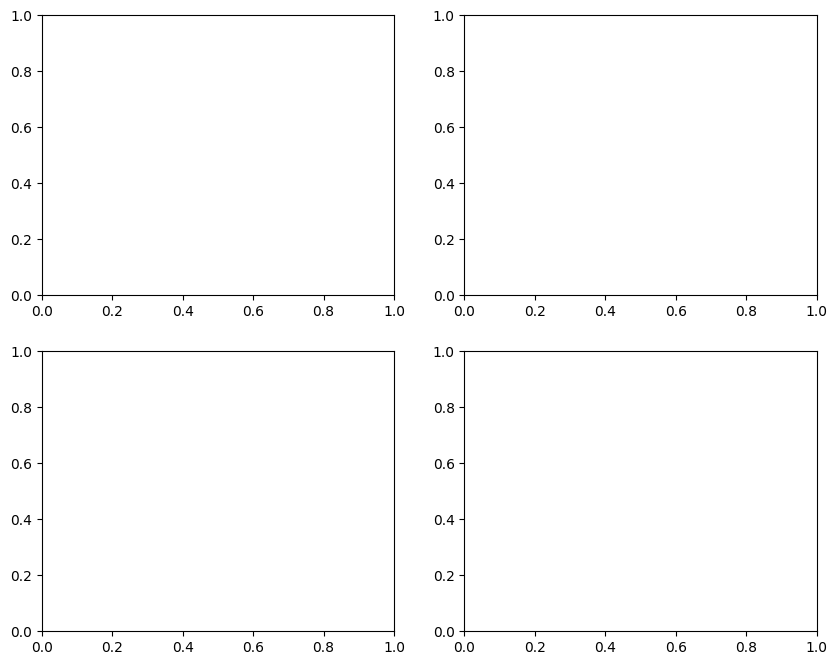

In [ ]:
plot_prior_sample_histograms(prior_samplers, config)

In [5]:
for prior in priors:
    normalization = describe_prior_normalization(prior)
    normalization_value = normalization["value"]
    if normalization["label"] == "Integral over box" and normalization_value is None:
        normalization_value = integrate_nd_vegas(
            prior,
            [(param_min, param_max)] * config["data"]["n_parameters"],
            nitn=20,
            neval=10_000,
        )[0]
    print(f"{normalization['label']} for {prior.__name__}: {normalization_value:.5f}")


Integral over box for uniform: 1.00000
Integral over box for normal: 1.00000
Integral over box for exponential: 1.00000
Discrete mass for grid: 1.00000


#### Data:

In [6]:
example_train_set, example_validation_set, example_test_set = get_data(
    prior_samplers[0],
    config,
    generator,
    show_output=True,
)

Train: torch.Size([70000, 1]), torch.Size([70000]), torch.Size([70000, 1])
Test: torch.Size([15000, 1]), torch.Size([15000]), torch.Size([15000, 1])
Validation: torch.Size([15000, 1]), torch.Size([15000]), torch.Size([15000, 1])


#### Run:

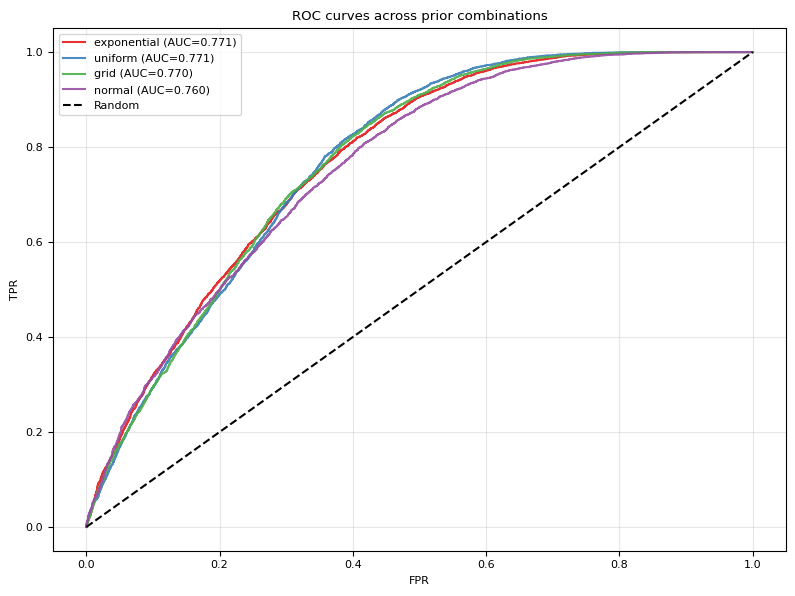

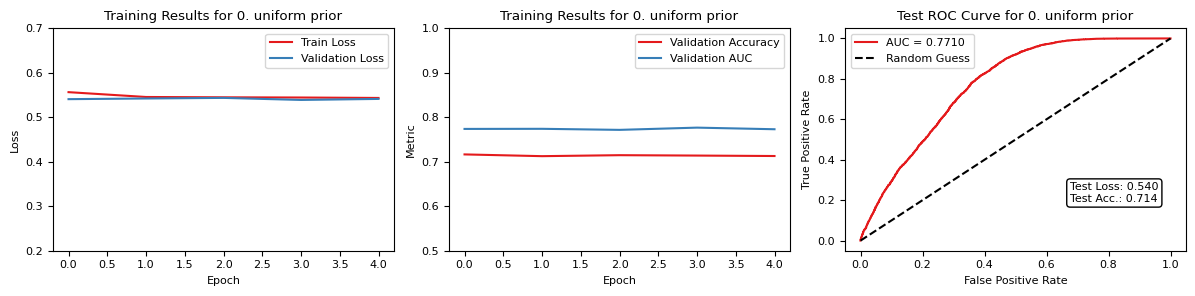

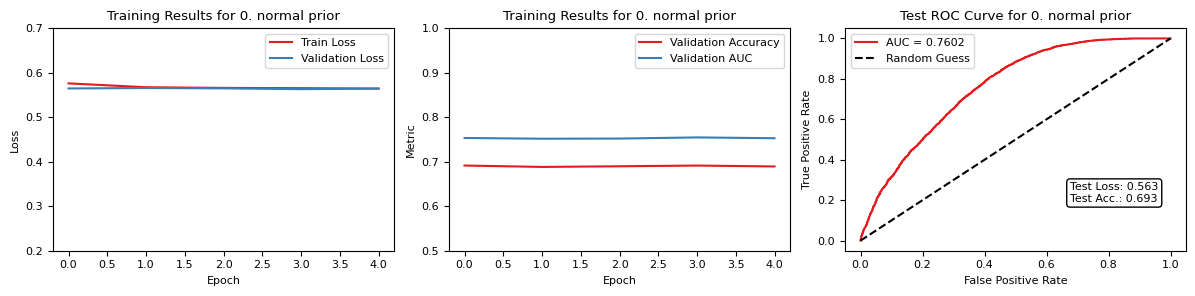

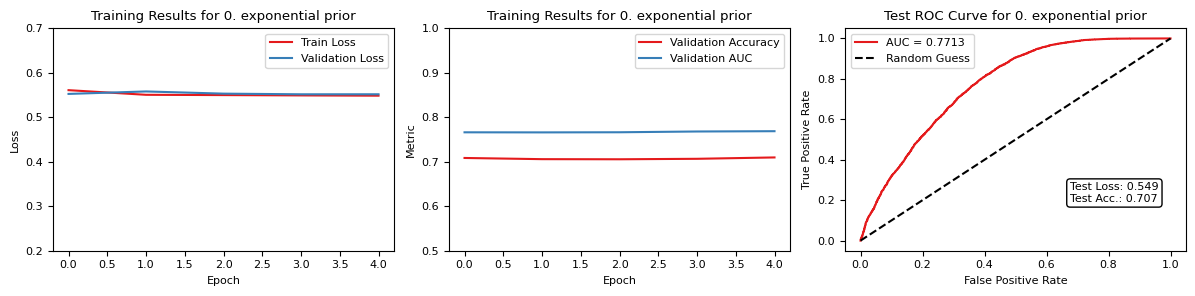

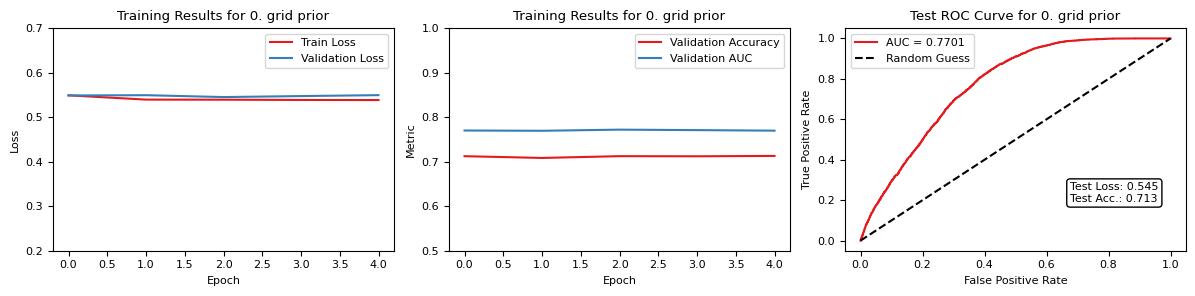

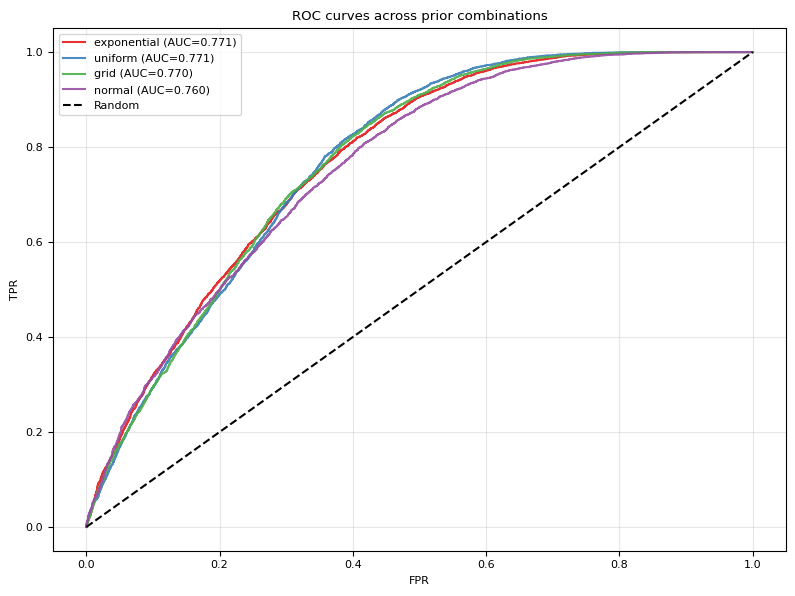

In [7]:
models = [{} for _ in range(config["training"]["model_iterations"])]
test_results = [{} for _ in range(config["training"]["model_iterations"])]

for prior_sampler in prior_samplers:
    prior_name = prior_sampler.__name__
    for i in range(config["training"]["model_iterations"]):
        train_set, validation_set, test_set = get_data(
            prior_sampler,
            config,
            generator,
            show_output=False,
        )
        model = BinaryClassifier(config)
        model, training_results = train(
            model,
            *train_set,
            *validation_set,
            config=config,
            device=device,
            show_output=False,
        )
        filename_plots = get_filepath(f"training/training_{i}/training_{prior_name}_prior.svg", config)
        filename_model = get_filepath(f"models/models_{i}/model_{prior_name}_prior.pth", config)
        torch.save(model.state_dict(), filename_model)
        test_result = test_model(model, *test_set, device=device, show_output=False)
        plot_training_tests(training_results, test_result, f"{i}. {prior_name}", filename_plots)
        models[i][prior_name] = model
        test_results[i][prior_name] = test_result

plot_all_rocs(test_results, filename=get_filepath("training/all_roc_curves.svg", config))

#### Posterior:

In [8]:
save = True
n_repititions_per_parameter = 15
n_parameters = int(2e2)

posterior_qmc_samples = 2**16
posterior_eval_batch_size = 2**15
posterior_max_model_evals_per_prior = int(2e15)
posterior_qmc_seed = 2026

parameters_min_max = config["data"]["parameter_range"]
all_parameters_in_range = [
    np.linspace(parameters_min_max[0], parameters_min_max[1], n_parameters)
    for _ in range(config["data"]["n_parameters"])
]
print(f"GPU: {device.type}; CPUs: {mp.cpu_count()}")

filename_errorbars = get_filepath("posterior_errors/errorbars.svg", config) if save else None
filename_errorbars_ratios = get_filepath("posterior_errors/errorbars_ratios.pdf", config) if save else None
filename_error_and_hld_width = get_filepath("posterior_errors/error_and_hpd_width.svg", config) if save else None
filename_error_and_hld_width_ratios = get_filepath("posterior_errors/error_and_hpd_width_ratios.svg", config) if save else None
filename_posteriors_data = get_filepath("posterior_errors/results_data.pkl", config) if save else None


GPU: cuda; CPUs: 96


In [9]:
inference_data = create_inference_data(
    parameters_min_max,
    config,
    generator,
    n_parameters_to_infer_per_dim=25,
    margin=0,
    n_repititions_per_parameter=n_repititions_per_parameter,
    support_axes=alignment_support_axes,
)
all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio = get_posteriors_and_errors(
    inference_data,
    all_parameters_in_range,
    models=models,
    priors=priors,
    device=device,
    n_qmc_samples=posterior_qmc_samples,
    eval_batch_size=posterior_eval_batch_size,
    max_model_evals_per_prior=posterior_max_model_evals_per_prior,
    qmc_seed=posterior_qmc_seed,
)

if save:
    with open(filename_posteriors_data, "wb") as handle:
        pickle.dump(
            {
                "all_HPDs_posterior": all_HPDs_posterior,
                "all_HPDs_ratio": all_HPDs_ratio,
                "inference_data": inference_data,
                "all_posteriors": all_posteriors,
                "all_ratios": all_ratios,
                "all_parameters_in_range": all_parameters_in_range,
                "n_repititions_per_parameter": n_repititions_per_parameter,
                "n_parameters": n_parameters,
            },
            handle,
        )


[posterior] eval_batch_size=32768, combo_batch_size=2, obs_chunk_size=30, theta_chunk_size=1092, forward_pairs=32760, qmc_samples=65536


Calculating posteriors and errors (QMC samples)...:   0%|                                                                    | 0/1500 [00:00<?, ?it/s]

Calculating posteriors and errors (QMC samples)...: 100%|████████████████████████████████████████████████████████| 1500/1500 [00:01<00:00, 892.36it/s]


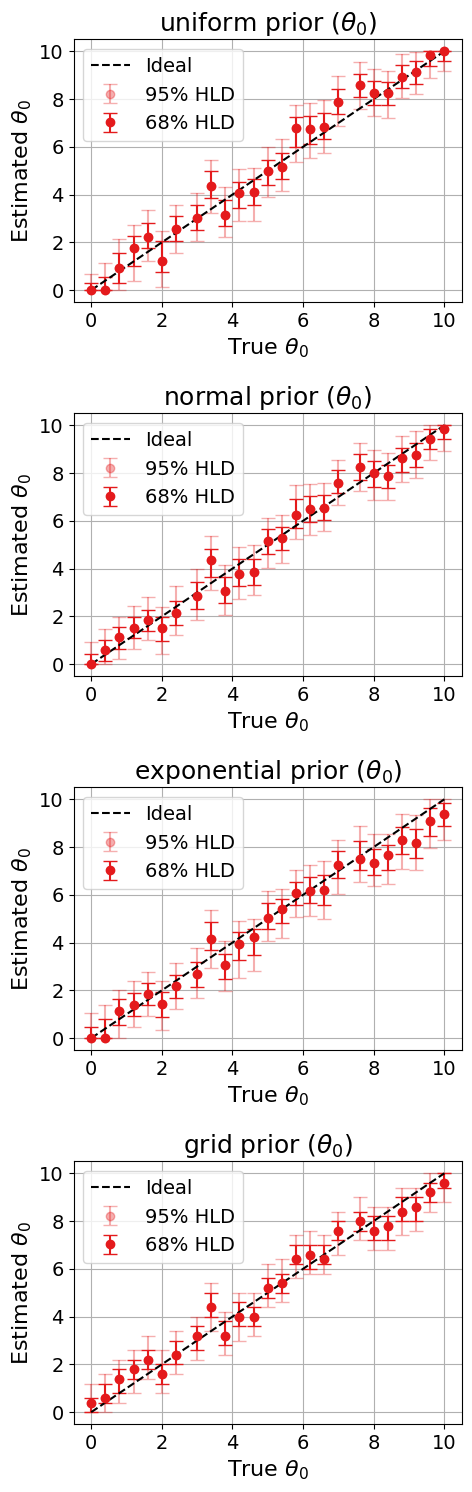

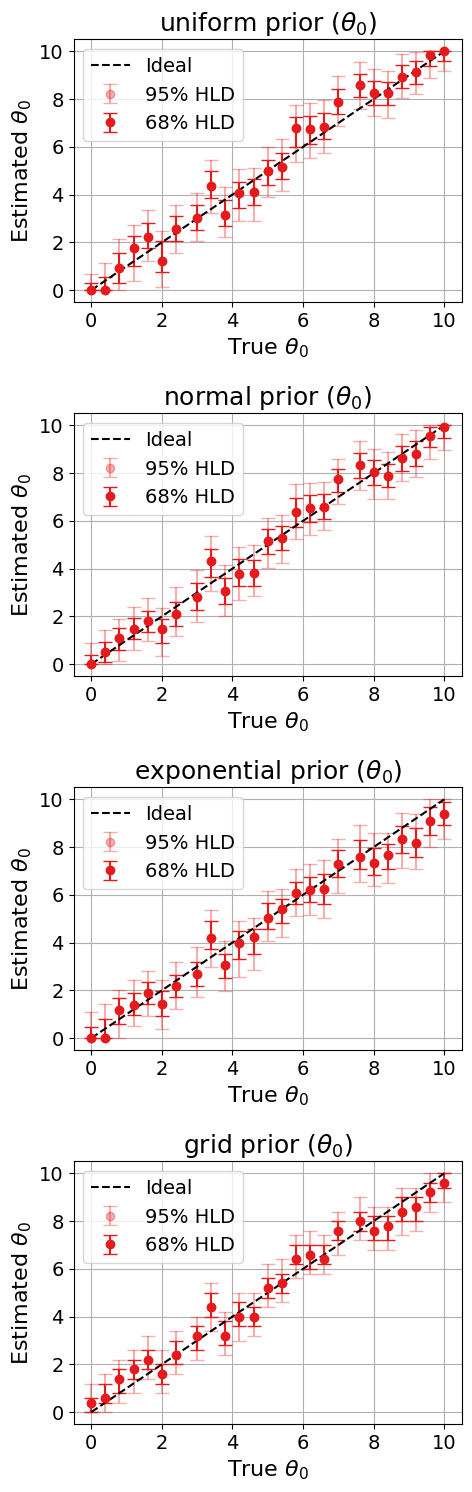

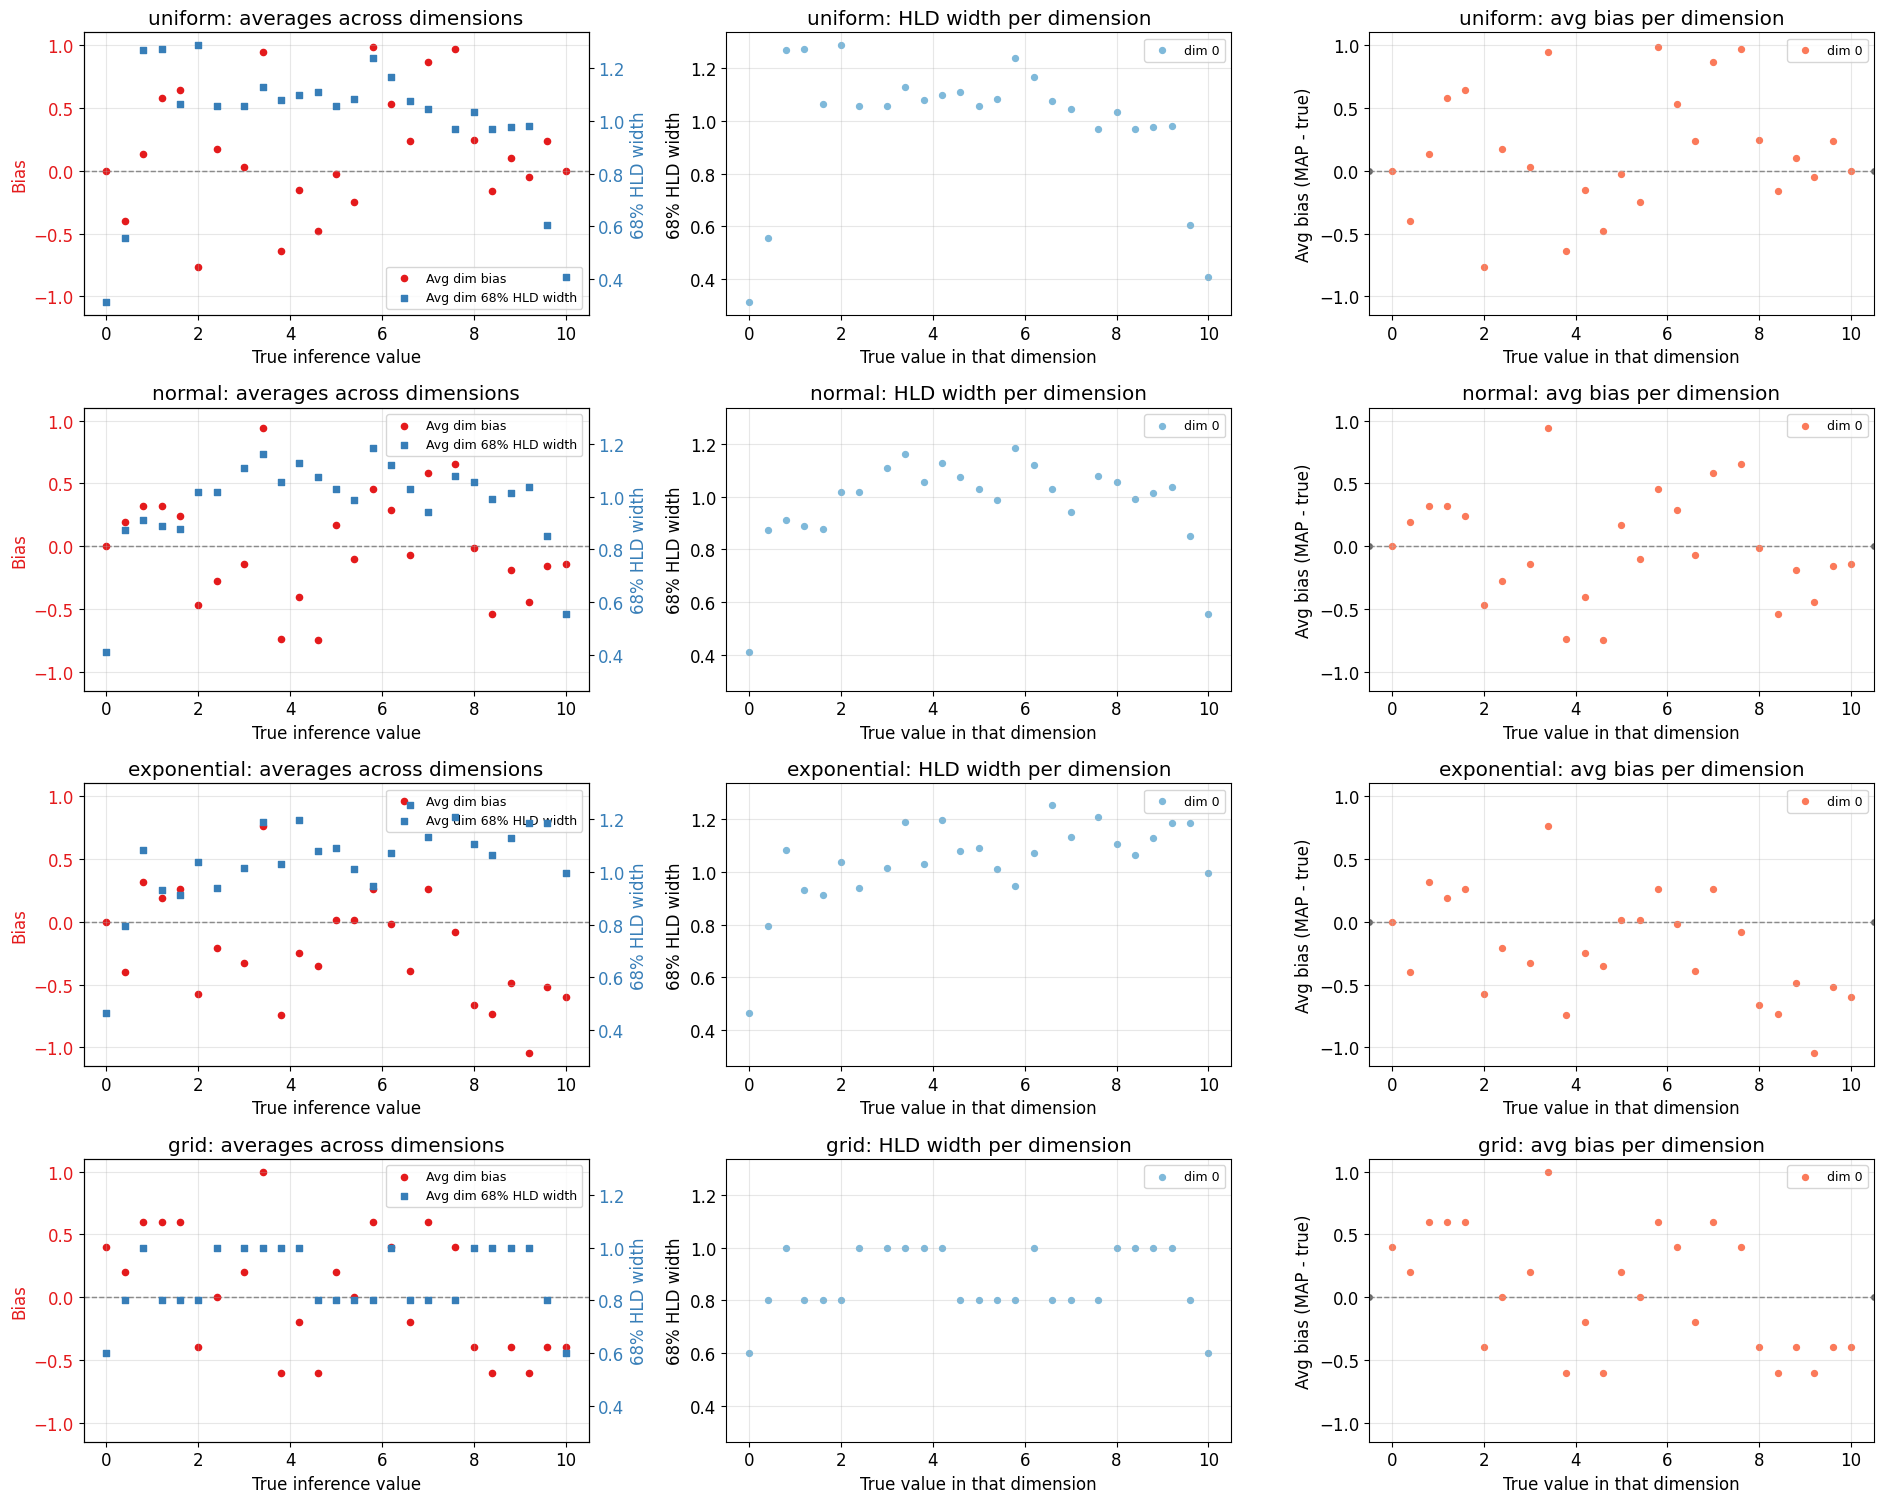

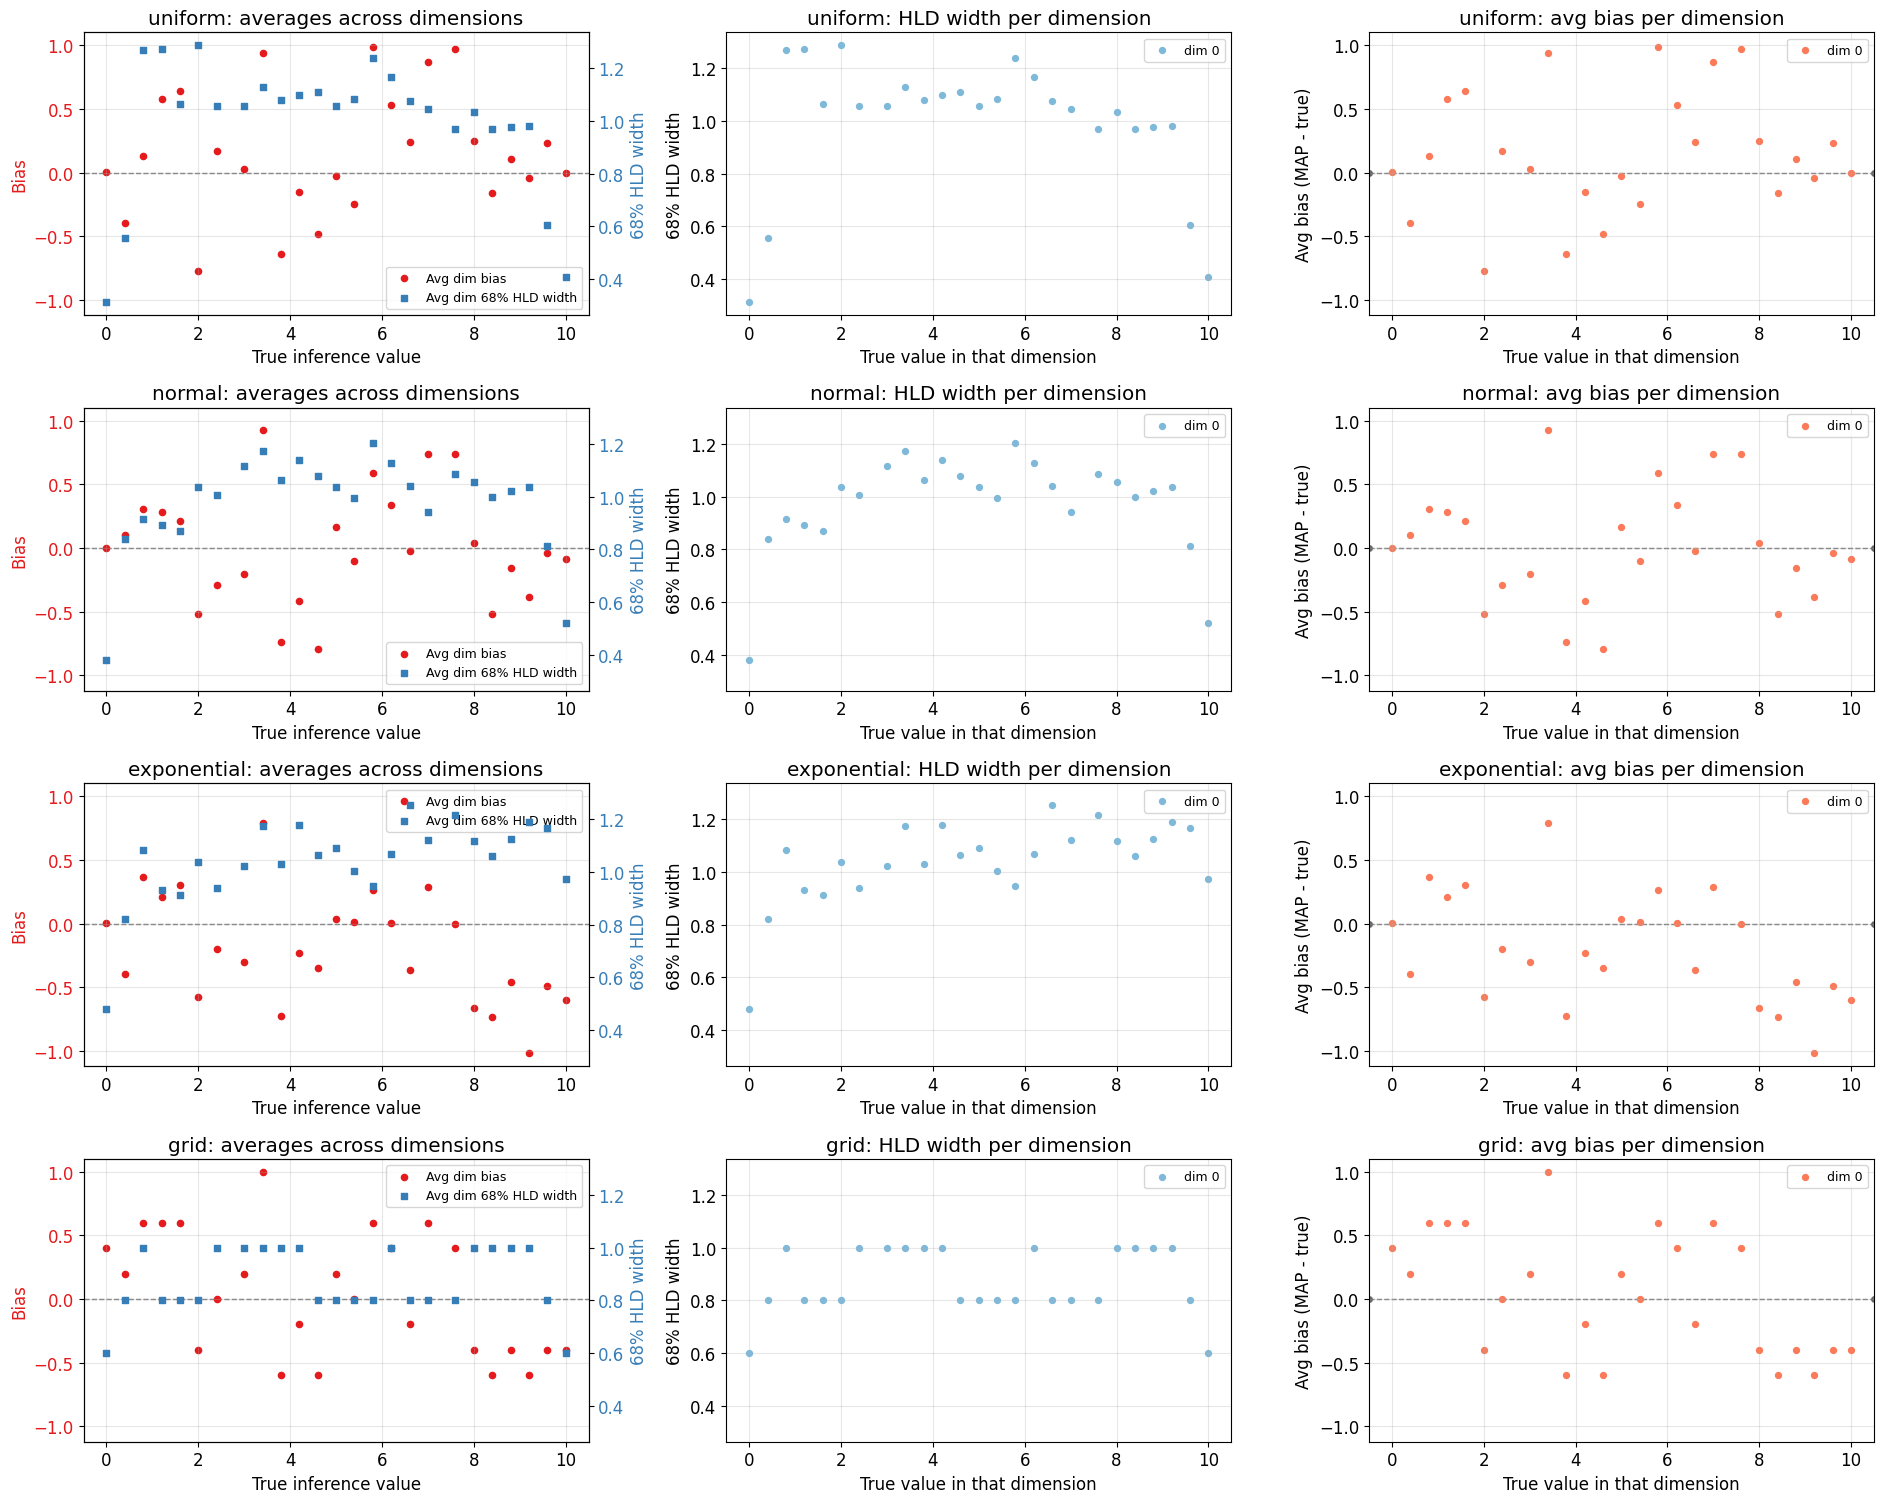

In [10]:
plot_errorbars(
    all_HPDs_posterior,
    inference_data,
    all_posteriors,
    all_parameters_in_range,
    show_annotations=False,
    filename=filename_errorbars,
)
plot_errorbars(
    all_HPDs_ratio,
    inference_data,
    all_ratios,
    all_parameters_in_range,
    show_annotations=False,
    filename=filename_errorbars_ratios,
)

fig, _ = plot_error_and_hld_width(
    all_HPDs_posterior,
    inference_data,
    all_posteriors,
    all_parameters_in_range,
    filename=filename_error_and_hld_width,
)
_enforce_markers(fig, filename=filename_error_and_hld_width)

fig, _ = plot_error_and_hld_width(
    all_HPDs_ratio,
    inference_data,
    all_ratios,
    all_parameters_in_range,
    filename=filename_error_and_hld_width_ratios,
)
_enforce_markers(fig, filename=filename_error_and_hld_width_ratios);

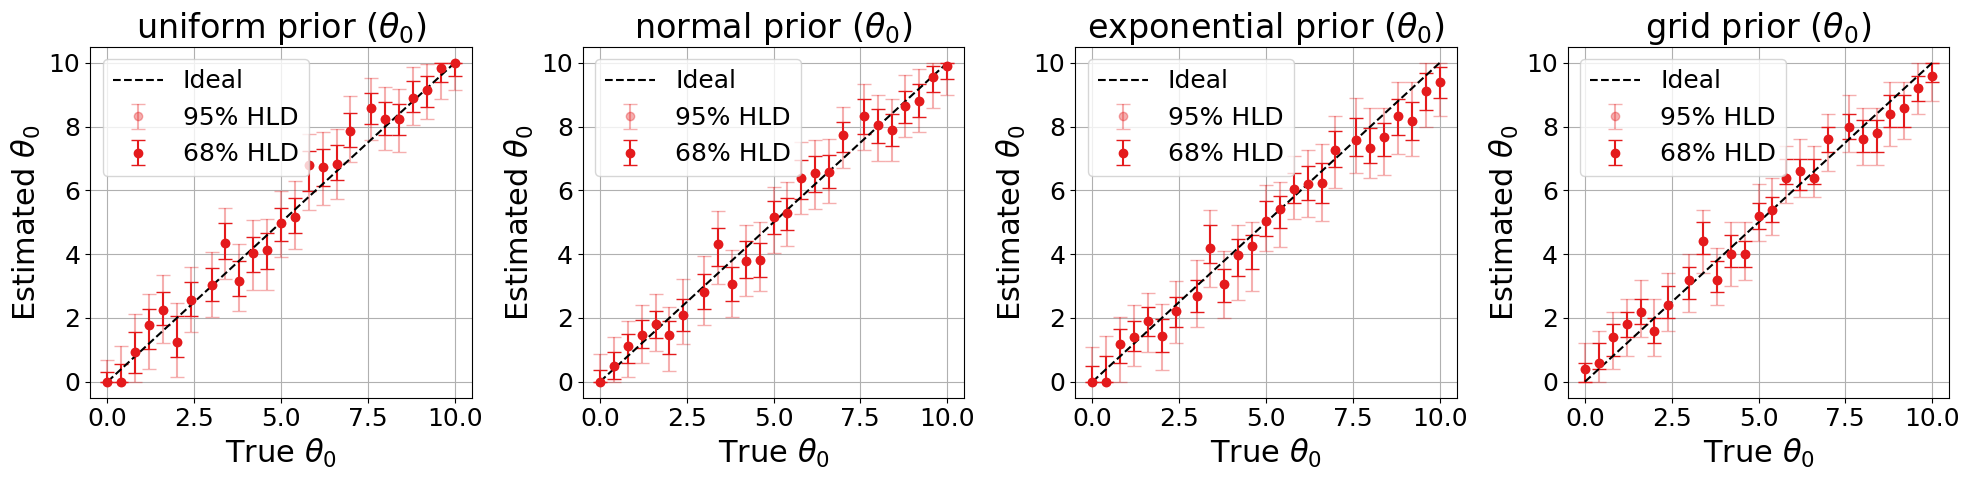

In [11]:
filename_errorbars_ratios_horizontal = (
    get_filepath("posterior_errors/errorbars_ratios_horizontal.pdf", config) if save else None
)
plot_errorbars(
    all_HPDs_ratio,
    inference_data,
    all_ratios,
    all_parameters_in_range,
    show_annotations=False,
    filename=filename_errorbars_ratios_horizontal,
    layout="horizontal",
);

In [12]:
filename_errorbars_ratios_horizontal

PosixPath('figs/config_020/posterior_errors/errorbars_ratios_horizontal.pdf')

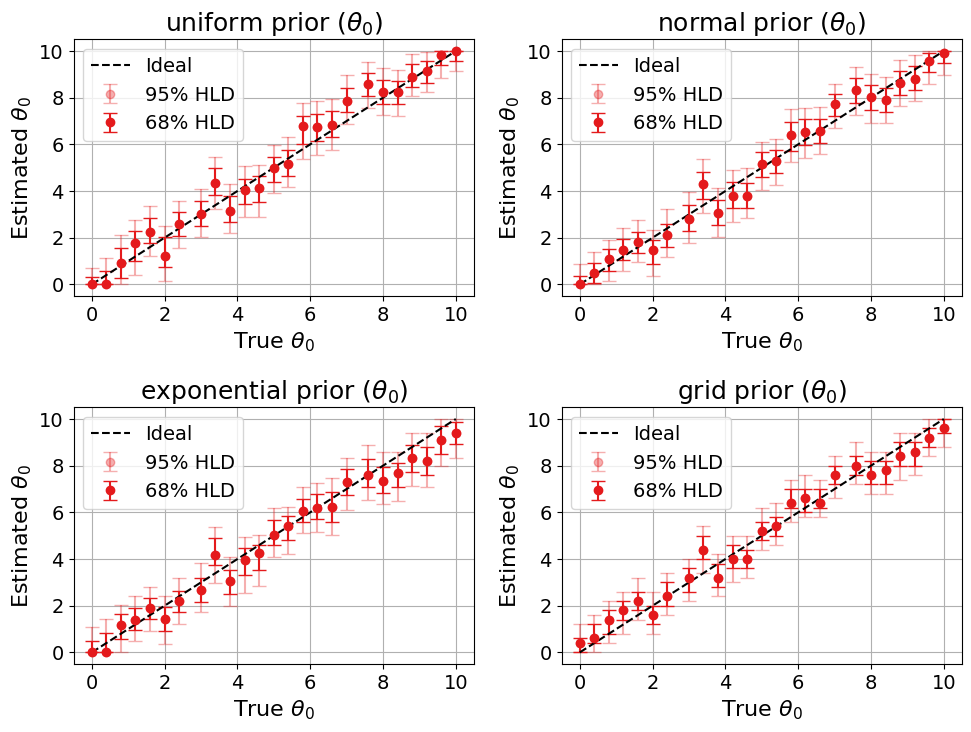

In [13]:
if config["data"]["n_parameters"] == 1:
    filename_errorbars_ratios_grid = (
        get_filepath("posterior_errors/errorbars_ratios_2x2.pdf", config) if save else None
    )
    plot_errorbars(
        all_HPDs_ratio,
        inference_data,
        all_ratios,
        all_parameters_in_range,
        show_annotations=False,
        filename=filename_errorbars_ratios_grid,
        layout="grid",
    );
else:
    print("2x2 errorbar ratios grid skipped: config is not 1D.")


In [14]:
averaged_bias_error = get_first_column_scatter_data(
    inference_data,
    all_ratios,
    all_parameters_in_range,
    all_HPDs_ratio,
)
averaged_bias_error

{'uniform': {'x': array([ 0.        ,  0.40000001,  0.80000001,  1.20000005,  1.60000002,
          2.        ,  2.4000001 ,  3.        ,  3.4000001 ,  3.79999995,
          4.19999981,  4.5999999 ,  5.        ,  5.4000001 ,  5.80000019,
          6.19999981,  6.5999999 ,  7.        ,  7.5999999 ,  8.        ,
          8.39999962,  8.80000019,  9.19999981,  9.60000038, 10.        ]),
  'avg_bias': array([ 1.34771690e-04, -3.99865240e-01,  1.31249309e-01,  5.80850244e-01,
          6.43600345e-01, -7.70499825e-01,  1.70564175e-01,  3.03864479e-02,
          9.42076206e-01, -6.41850710e-01, -1.51309490e-01, -4.82147694e-01,
         -2.60486603e-02, -2.45216370e-01,  9.84982491e-01,  5.32480240e-01,
          2.40724564e-01,  8.68849754e-01,  9.73145008e-01,  2.48446465e-01,
         -1.58596039e-01,  1.02688789e-01, -4.66613770e-02,  2.35418320e-01,
         -1.04904175e-04]),
  'avg_width_68': array([0.31190044, 0.55633116, 1.26989746, 1.27503276, 1.06505167,
         1.28820908, 1.05

#### Posterior Checks:

Check I: ratio expectation value

For each prior $p_i(\theta)$, this identity is checked using data drawn from that prior's own induced marginal
$ p_i(x) = \int p(x\mid\theta) p_i(\theta) \, d\theta $.

$1=\int p(x|\theta_0) dx = \int r_i(x|\theta_0) p_i(x) dx = \mathbb{E}_{p_i(x)} [r_i(x|\theta_0)]$

So if $\mathbb{E}_{p_i(x)} [r_i(x|\theta_0)]=1$, then $r_i(x|\theta_0) = p(x|\theta_0) / p_i(x) = p_i(\theta_0 | x) / p_i(\theta_0)$ is plausible for that prior-specific marginal.


(<Figure size 1200x800 with 4 Axes>,
 array([<Axes: title={'center': 'uniform prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>,
        <Axes: title={'center': 'normal prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>,
        <Axes: title={'center': 'exponential prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>,
        <Axes: title={'center': 'grid prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>],
       dtype=object))

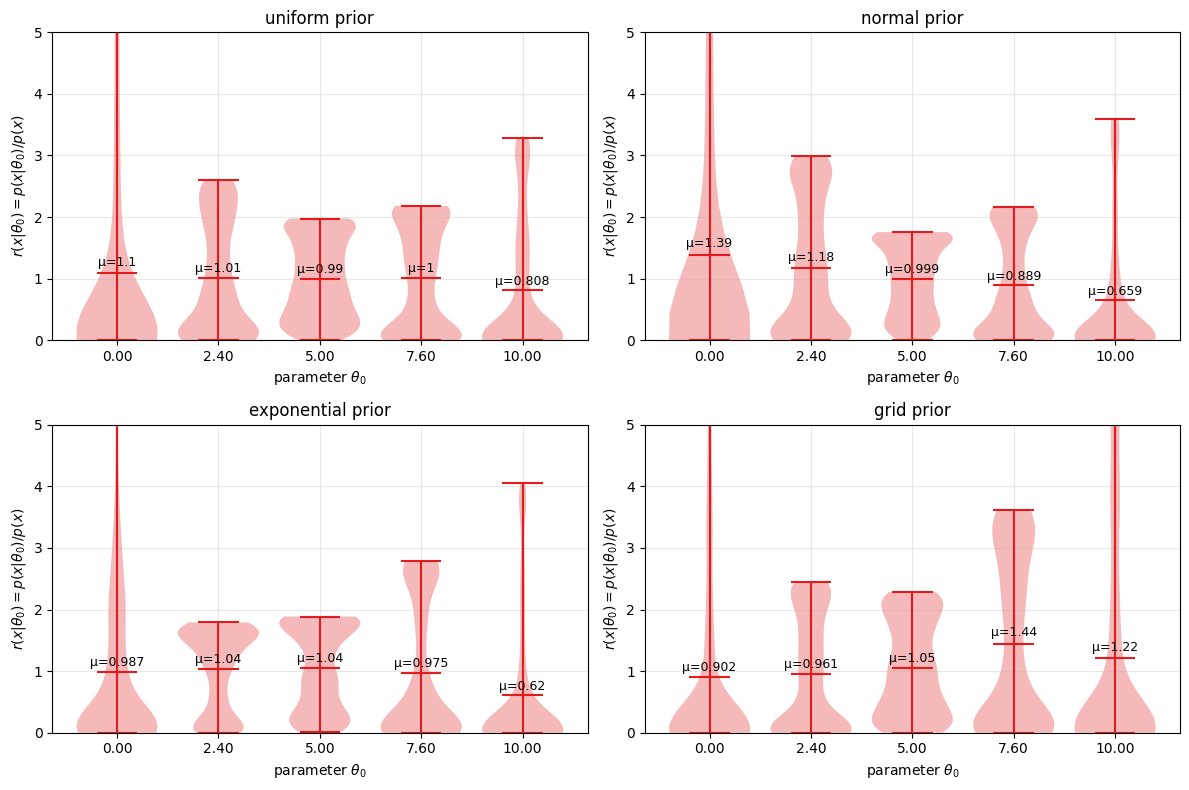

In [15]:
n_ratio_samples = 1_000
verification_data_by_prior = {}
for prior_sampler in prior_samplers:
    verification_parameters = prior_sampler((n_ratio_samples,))
    verification_data_by_prior[prior_sampler.__name__] = draw_data(
        verification_parameters,
        config,
        generator,
    )

test_parameters = create_inference_parameters(
    5,
    config["data"]["parameter_range"],
    generator,
    margin=0.0,
    data_is_random=False,
    support_axis=None if alignment_support_axes is None else alignment_support_axes[0],
)
all_ratio_checks = calculate_all_ratios(
    verification_data_by_prior,
    test_parameters,
    models=models,
    priors=priors,
    device=device,
)

filename_ratio_violins = get_filepath("verifications/ratio_violins.svg", config) if save else None
plot_ratio_violins(all_ratio_checks, test_parameters, filename=filename_ratio_violins)


#### Check II: reweighting

$R_{10}(x) = \frac{r(x|\theta_1)}{r(x|\theta_0)} = \frac{p(x|\theta_1)}{p(x|\theta_0)}$

if $p(x|\theta_1) = R_{10}(x)p(x|\theta_0)$: likelihood ratio trick holds

For the nD case below, the ratios use the full data vector while the plot visualizes the first observed component.

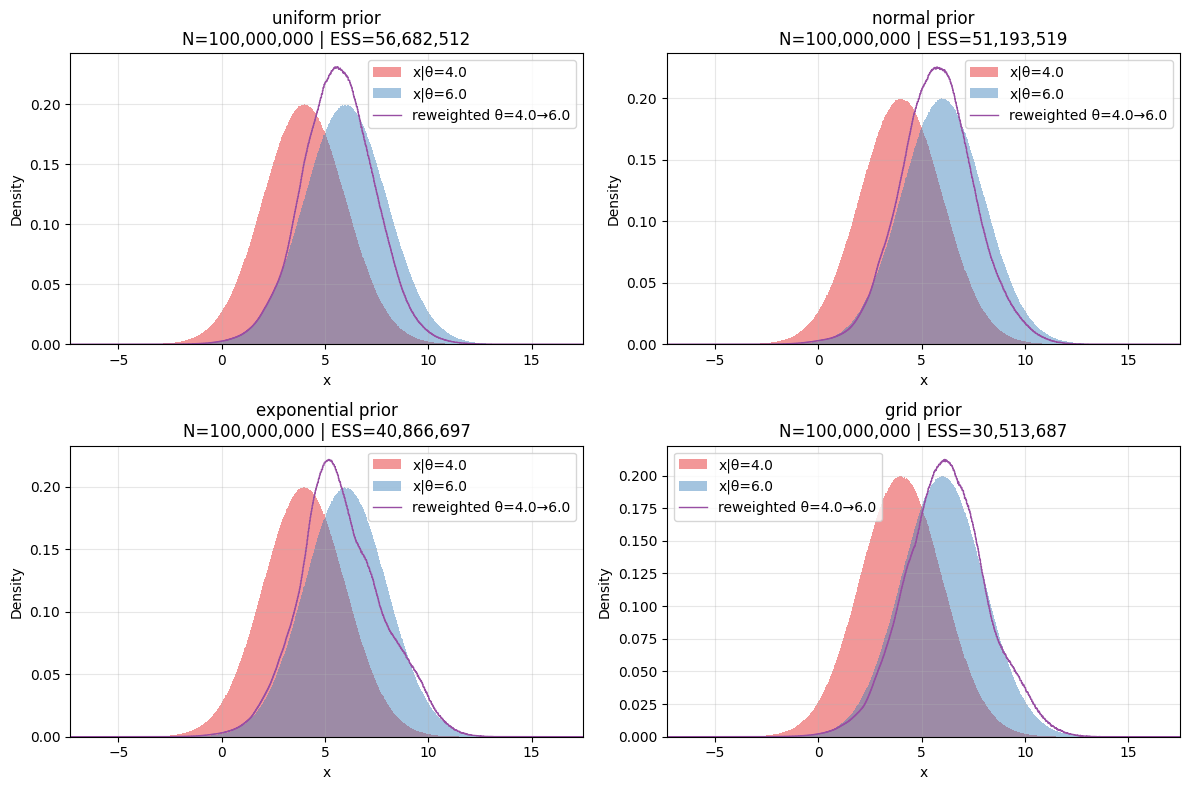

In [16]:
n_test_data = int(1e8)
n_bins = int(1e3)
if alignment_support_axes is None:
    test_parameter_sets = [(4, 6)]
else:
    test_parameter_sets = [
        (
            snap_to_support_axis(4, alignment_support_axes[0]),
            snap_to_support_axis(6, alignment_support_axes[0]),
        )
    ]

for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameter_sets:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(
            test_parameter_set,
            model_arr,
            priors=priors,
            config=config,
            generator=generator,
            device=device,
            n_test_data=n_test_data,
            n_bins=n_bins,
            projection_dim=0,
        )
        filename_reweighted_distributions = get_filepath(
            f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg",
            config,
        ) if save else None
        plot_reweighted_distributions(
            priors,
            data_x,
            reweighted_distributions,
            test_parameter_set,
            n_bins,
            reweighting_distributions=reweighting_distributions,
            filename=filename_reweighted_distributions,
        )


#### Check III: exact pairwise log-ratio error

Use the analytic Gaussian pairwise likelihood ratio as the reference target:

$\log R_{10}(x) = \frac{\lVert x-\theta_0\rVert^2 - \lVert x-\theta_1\rVert^2}{2\sigma^2}$

The learned score is $\log \hat{R}_{10}(x) = \operatorname{logit}(\hat{r}(x|\theta_1)) - \operatorname{logit}(\hat{r}(x|\theta_0))$. We evaluate many full-vector $(\theta_0, \theta_1)$ pairs and summarize the per-pair RMSE against the exact value.

uniform {'median_rmse_log_r10': 0.3865706579713228, 'worst_rmse_log_r10': 3.886856956341513, 'pooled_rmse_log_r10': 1.0857668555480755, 'spearman_rmse_vs_distance': 0.9946231915992393}
normal {'median_rmse_log_r10': 0.28557400019989954, 'worst_rmse_log_r10': 4.059465701726746, 'pooled_rmse_log_r10': 1.1005241032758242, 'spearman_rmse_vs_distance': 0.9928852278108252}
exponential {'median_rmse_log_r10': 0.38599996751137744, 'worst_rmse_log_r10': 3.915564628586345, 'pooled_rmse_log_r10': 1.0599367752270876, 'spearman_rmse_vs_distance': 0.9787579679320453}
grid {'median_rmse_log_r10': 0.2760586605702451, 'worst_rmse_log_r10': 3.024121242979498, 'pooled_rmse_log_r10': 0.7770597872241178, 'spearman_rmse_vs_distance': 0.983349139611009}


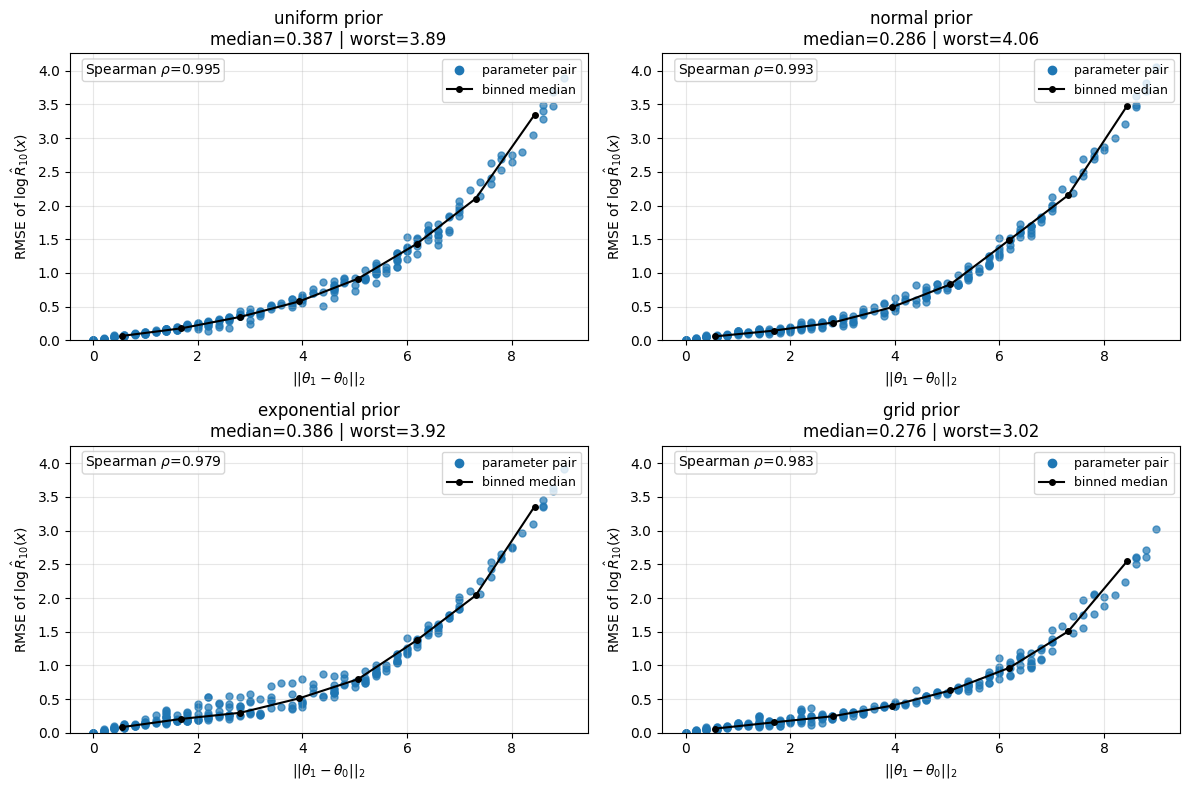

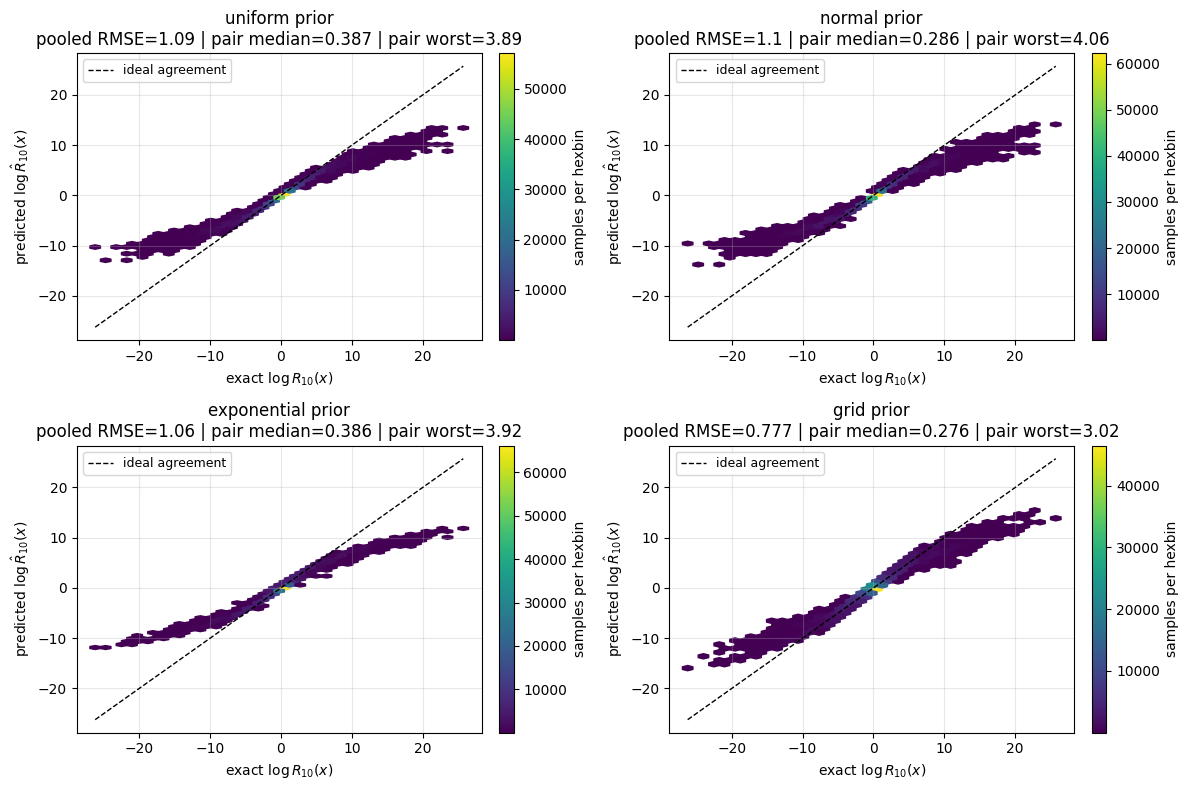

In [17]:
verification_pair_count = 256
verification_model_samples_per_endpoint = 512
verification_reweight_source_samples = 2_048
verification_reweight_target_samples = 2_048
verification_swd_projections = 32

quantitative_bundle = build_quantitative_verification_bundle(
    config=config,
    generator=generator,
    pair_count=verification_pair_count,
    model_samples_per_endpoint=verification_model_samples_per_endpoint,
    reweight_source_samples=verification_reweight_source_samples,
    reweight_target_samples=verification_reweight_target_samples,
    swd_projections=verification_swd_projections,
    support_axes=alignment_support_axes,
)

model_quality_results = evaluate_pairwise_log_ratio_quality(
    quantitative_bundle,
    models=models,
    priors=priors,
    device=device,
)

for prior_name, result in model_quality_results.items():
    print(prior_name, result["summary"])

filename_log_ratio_error_vs_distance = get_filepath("verifications/log_ratio_error_vs_distance.svg", config) if save else None
fig, _ = plot_log_ratio_error_vs_distance(
    model_quality_results,
    filename=filename_log_ratio_error_vs_distance,
)
#plt.close(fig)

filename_log_ratio_exact_vs_predicted = get_filepath("verifications/log_ratio_exact_vs_predicted.svg", config) if save else None
fig, _ = plot_log_ratio_exact_vs_predicted(
    model_quality_results,
    filename=filename_log_ratio_exact_vs_predicted,
)
#plt.close(fig)

model_quality_json = {
    prior_name: {
        "summary": {
            key: (None if np.isnan(float(value)) else float(value))
            for key, value in result["summary"].items()
        },
        "pair_metrics": {
            key: np.asarray(value, dtype=float).tolist()
            for key, value in result["pair_metrics"].items()
        },
    }
    for prior_name, result in model_quality_results.items()
}
filename_model_quality_json = get_filepath("verifications/model_quality_summary.json", config) if save else None
if filename_model_quality_json is not None:
    filename_model_quality_json.write_text(json.dumps(model_quality_json, indent=2, sort_keys=True))


#### Check IV: nD reweighting quality

Use weighted sliced Wasserstein-1 (SW1) as a bin-free nD reweighting metric. For each sampled pair $(\theta_0, \theta_1)$, compare the direct target sample $x_1 \sim p(x|\theta_1)$ against the source sample $x_0 \sim p(x|\theta_0)$ reweighted by the learned pairwise score. Report SW1, ESS, ESS fraction, and how the score changes with $\lVert \theta_1 - \theta_0 \rVert$.

In [18]:

%matplotlib inline
with open(filename_posteriors_data, "rb") as handle:
    posterior_payload = pickle.load(handle)
all_HPDs_posterior = posterior_payload["all_HPDs_posterior"]
all_HPDs_ratio = posterior_payload["all_HPDs_ratio"]
inference_data = posterior_payload["inference_data"]
all_posteriors = posterior_payload["all_posteriors"]
all_ratios = posterior_payload["all_ratios"]
all_parameters_in_range = posterior_payload["all_parameters_in_range"]
